# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sherlock Chen

**Date:** 9/6/2026

In [10]:
# Question 1.1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "./data/airbnb_hw.csv"
df = pd.read_csv(path)

# Price is type string and also has commas for some values so remove commas and convert to numeric
print(df["Price"].dtype)
df["Price_Clean"] = pd.to_numeric(df["Price"].str.replace(",", "", regex=False), errors="coerce")

# Sort prices by ascending to make more clean and organized 
df = df.sort_values(by="Price_Clean", ascending=True)

# print total missing values
total_missing = df["Price_Clean"].isna().sum()
print(f"Total Missing: {total_missing}") 


str
Total Missing: 0


In [12]:
# Question 1.2
path = "./data/mn_police_use_of_force.csv"
df = pd.read_csv(path)

# Find proportion of "subject injury" missing by getting total null rows in the column and total rows
df["null_subject_injury"] = df["subject_injury"].isnull()
total_null = df["null_subject_injury"].sum()
total_rows = len(df)

# About 76% of the data is missing, which is a concern because the proportion is so high
proportion_null = total_null / total_rows
print(f"Proportion of Subject_Injury Null: {proportion_null}") 

# Imputate with the impute value of "missing"
impute_value = "missing"
df["imputated_subject_injury"] = df["subject_injury"].fillna(impute_value)

# After cross-tabulation, the pattern is that most of the data missing is from the force type of bodily force
# Other missing values (but not as many as bodily force) are mainly chemical irritant, taser, and maximal restraint technique
# This pattern may mean that these injuries from these force types are easier to hide and not reported making a lot of them missing
crosstab = pd.crosstab(df["imputated_subject_injury"], df["force_type"])
print(crosstab)

Proportion of Subject_Injury Null: 0.7619342359767892
force_type                Baton  Bodily Force  Chemical Irritant  Firearm  \
imputated_subject_injury                                                    
No                            0          1093                131        2   
Yes                           2          1286                 41        0   
missing                       2          7051               1421        0   

force_type                Gun Point Display  Improvised Weapon  Less Lethal  \
imputated_subject_injury                                                      
No                                       33                 34            0   
Yes                                      44                 40            0   
missing                                  27                 74           87   

force_type                Less Lethal Projectile  Maximal Restraint Technique  \
imputated_subject_injury                                                        
No

float64
Min Year: 0
Max Year: 2026


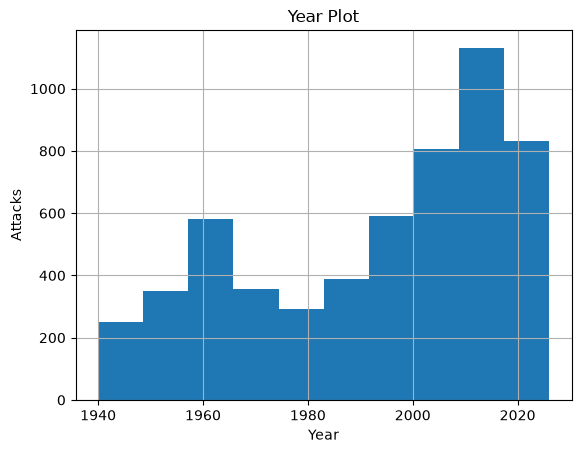

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


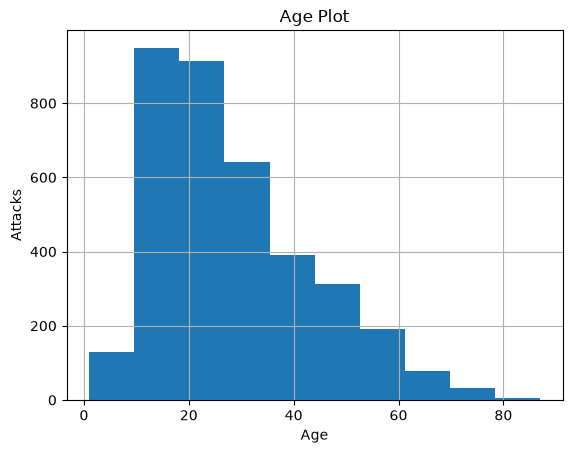

Male proportion: 0.8545808966861599
<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'UNprovoked',          'unprovoked',           ' Provoked',
          'Watercraft',        'Sea Disaster',                   nan,
                   '?',         'Unconfirmed',          'Unverified',
             'Invalid', 'Under investigation',                'Boat']
Length: 15, dtype: str
str
Unprovoked Proportion: 0.7459236695932628


In [ ]:
# Question 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "./data/GSAF5.xls"
df = pd.read_excel(path)

# Drop columns that have no values at all
df = df.dropna(axis=1, how="all") 

# "Year" column type is float so convert to int
print(df["Year"].dtype)
df["Year_Clean"] = df["Year"].astype("Int64")

# The min year is 0 and max year is 2026
min_year = df["Year_Clean"].min()
max_year = df["Year_Clean"].max()
print(f"Min Year: {min_year}")
print(f"Max Year: {max_year}")

# Filter to only years since 1940 and create plot to see the trend
# According to the plot, the attacks are generally increasing over time
df = df[df["Year_Clean"] >= 1940]
df["Year_Clean"].hist()
plt.title("Year Plot")
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.show()

# Age has strings inside it and also type object so convert to numeric
print(df["Age"].unique())
print(df["Age"].dtype)
df["Age_Clean"] = pd.to_numeric(df["Age"], errors="coerce")

# Create histogram of age
df["Age_Clean"].hist()
plt.title("Age Plot")
plt.xlabel("Age")
plt.ylabel("Attacks")
plt.show()

# About 85% of the victims are male
male_count = (df["Sex"] == "M").sum()
total_sex = df["Sex"].notna().sum()
male_proportion = male_count / total_sex
print(f"Male proportion: {male_proportion}")

# Values in "Type" column are have different capitalizations so make function to normalize capitalization and assign unknown to ones that don't fit any category
print(df["Type"].unique())
print(df["Type"].dtype)

def normalize_type(type_value):
    normalized_type_value = str(type_value).capitalize()

    if normalized_type_value == "Provoked":
        return "Provoked"
    elif normalized_type_value == "Unprovoked":
        return "Unprovoked"
    else:
        return "Unknown"

# Apply function to column and assign to clean column
df["Type_Clean"] = df["Type"].apply(normalize_type)

# The unprovoked proportion is about 75%
unprovoked_count = (df["Type_Clean"] == "Unprovoked").sum()
total_rows = len(df)
unprovoked_proportion = unprovoked_count / total_rows
print(f"Unprovoked Proportion: {unprovoked_proportion}")

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 295e132c7909f4f7e0b51cf58210f4ec84d9e2bb
- **AI tool and model used:** Gemini 3.6 Flash

### *Prompts used

[For Question 1.1]
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?) 

```python
# Question 1.1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "./data/airbnb_hw.csv"
df = pd.read_csv(path)

# Price is type string and also has commas for some values so remove commas and convert to numeric
print(df["Price"].dtype)
df["Price_Clean"] = pd.to_numeric(df["Price"].str.replace(",", "", regex=False), errors="coerce")

# Sort prices by ascending to make more clean and organized 
df = df.sort_values(by="Price_Clean", ascending=True)

# print total missing values
total_missing = df["Price_Clean"].isna().sum()
print(f"Total Missing: {total_missing}") 
```

give me feedback on how i did and suggestions if any

[For Question 1.2]

2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?  

```python
# Question 1.2
path = "./data/mn_police_use_of_force.csv"
df = pd.read_csv(path)

# Find proportion of "subject injury" missing by getting total null rows in the column and total rows
df["null_subject_injury"] = df["subject_injury"].isnull()
total_null = df["null_subject_injury"].sum()
total_rows = len(df)

# About 76% of the data is missing, which is a concern because the proportion is so high
proportion_null = total_null / total_rows
print(f"Proportion of Subject_Injury Null: {proportion_null}") 

# Imputate with the impute value of "missing"
impute_value = "missing"
df["imputated_subject_injury"] = df["subject_injury"].fillna(impute_value)

# After cross-tabulation, the pattern is that most of the data missing is from the force type of bodily force
# Other missing values (but not as many as bodily force) are mainly chemical irritant, taser, and maximal restraint technique
# This pattern may mean that these injuries from these force types are easier to hide and not reported making a lot of them missing
crosstab = pd.crosstab(df["imputated_subject_injury"], df["force_type"])
print(crosstab)
```

give me feedback on how i did and suggestions if any

[For Question 2]

3. **Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

```python
# Question 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "./data/GSAF5.xls"
df = pd.read_excel(path)

# Drop columns that have no values at all
df = df.dropna(axis=1, how="all") 

# "Year" column type is float so convert to int
print(df["Year"].dtype)
df["Year_Clean"] = df["Year"].astype("Int64")

# The min year is 0 and max year is 2026
min_year = df["Year_Clean"].min()
max_year = df["Year_Clean"].max()
print(f"Min Year: {min_year}")
print(f"Max Year: {max_year}")

# Filter to only years since 1940 and create plot to see the trend
# According to the plot, the attacks are generally increasing over time
df = df[df["Year_Clean"] >= 1940]
df["Year_Clean"].hist()
plt.title("Year Plot")
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.show()

# Age has strings inside it and also type object so convert to numeric
print(df["Age"].unique())
print(df["Age"].dtype)
df["Age_Clean"] = pd.to_numeric(df["Age"], errors="coerce")

# Create histogram of age
df["Age_Clean"].hist()
plt.title("Age Plot")
plt.xlabel("Age")
plt.ylabel("Attacks")
plt.show()

# About 85% of the victims are male
male_count = (df["Sex"] == "M").sum()
total_sex = df["Sex"].notna().sum()
male_proportion = male_count / total_sex
print(f"Male proportion: {male_proportion}")

# Values in "Type" column are have different capitalizations so make function to normalize capitalization and assign unknown to ones that don't fit any category
print(df["Type"].unique())
print(df["Type"].dtype)

def normalize_type(type_value):
    normalized_type_value = str(type_value).capitalize()

    if normalized_type_value == "Provoked":
        return "Provoked"
    elif normalized_type_value == "Unprovoked":
        return "Unprovoked"
    else:
        return "Unknown"

# Apply function to column and assign to clean column
df["Type_Clean"] = df["Type"].apply(normalize_type)

# The unprovoked proportion is about 75%
unprovoked_count = (df["Type_Clean"] == "Unprovoked").sum()
total_rows = len(df)
unprovoked_proportion = unprovoked_count / total_rows
print(f"Unprovoked Proportion: {unprovoked_proportion}")
```

give me feedback on how i did and suggestions if any

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

[For Question 1.1]

1. Missing Dollar Signs ($): Airbnb price strings almost always include a dollar sign (e.g., "$675" or "$1,112.00"). If you only remove commas, strings like "$675" or "$1112" will fail to parse in pd.to_numeric() and get converted into NaN due to errors="coerce". You need to remove both $ and ,.
2. Sorting side-effects: df = df.sort_values(...) permanently reorders your original DataFrame rows. Unless the prompt specifically requests sorting the dataset by price, it is best not to reorder the dataset, as subsequent questions might rely on the original row index.

[For Question 1.2]

3. Recoding subject_injury to Yes / No

    Issue: The prompt asks to handle NAs such that the variable yields Yes when an injury occurred and No when no injury occurred. Your code replaced NA with "missing", creating a third category rather than a binary indicator.

    Fix: In this dataset, NA indicates no injury occurred. Impute missing values with "No":

    ```python
    df["subject_injury_cleaned"] = df["subject_injury"].fillna("No")
    ```

4. Code Efficiency for Missing Proportion

    Issue: Creating a new column df["null_subject_injury"] adds unnecessary overhead to the DataFrame.

    Fix: Calculate the proportion of missing values directly in one line using .isna().mean():

    ```python
    proportion_null = df["subject_injury"].isna().mean()
    print(f"Proportion of Subject_Injury Null: {proportion_null:.4f}")
    ```

5. Cross-Tabulation: Raw Counts vs. Relative Proportions

    Issue: Your conclusion that missing values occur primarily with bodily force relies on raw count frequencies. Because bodily force is the most common type of force used overall, it naturally accounts for the highest raw count of missing values.

    Fix: Use row proportions (normalize='index') to analyze the percentage of missingness or injuries within each force type:

    ```python
    # Cross-tabulation using proportions by force_type
    crosstab_prop = pd.crosstab(
        df["force_type"], 
        df["subject_injury"].isna(), 
        normalize="index"
    )
    print(crosstab_prop)
    ```

    Analyzing percentages across rows reveals whether certain force types actually have a disproportionately higher rate of missing injury records, rather than just higher total volume.

6. Substantive Interpretation & Terminology

    Terminology: The past participle of "impute" is imputed, not "imputated".

    Contextual Reasoning: Suggesting police hide injuries is a strong assumption. In administrative police data, missing injury records frequently occur because minor force events (like holding someone down using bodily force) rarely involve medical evaluation or documented injuries, leading officers to leave the field blank.

[For Question 2]

7. Cleaning the Sex Column (Task 5)
    In the GSAF dataset, the Sex column often contains whitespace, lower/upper-case variations (e.g., 'm', 'M '), or unexpected characters ('M ', 'N').

    Current Issue: Checking strictly df["Sex"] == "M" might miss lower-case 'm' or strings with trailing spaces.

    Improvement: Standardize string values before filtering:
    ```python
    # Strip whitespace and capitalize before checking
    sex_clean = df["Sex"].astype(str).str.strip().str.upper()
    male_count = (sex_clean == "M").sum()
    total_valid = sex_clean.isin(["M", "F"]).sum()

    male_proportion = male_count / total_valid
    print(f"Male proportion: {male_proportion:.2%}")
    ```

8. Year Filtering Edge Cases (Task 3)
    In historical data files, some entries have bad year annotations (e.g., 0 or placeholder values) or future/corrupted years.

    Improvement: Verify that Year_Clean filter excludes zeros before summarizing min/max:
    ```python
    # Check for valid non-zero years
    valid_years = df[df["Year_Clean"] > 0]["Year_Clean"]
    print(f"Historical Min Year: {valid_years.min()}")
    ```

9. Plot Customization
    Year Histogram: Standard histograms group continuous data into dynamic bins. For time-series analysis over discrete years, setting explicit bin counts or creating a bar plot grouped by decade/year gives a clearer picture of the trend.
    ```python
    plt.figure(figsize=(8, 4))
    df["Year_Clean"].hist(bins=30, edgecolor="black")
    plt.title("Shark Attacks Since 1940")
    plt.xlabel("Year")
    plt.ylabel("Number of Attacks")
    plt.tight_layout()
    plt.show()
    ```

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | Looking at the CSV file for Price, there are no $ so this is unecessary |
| 2 | Accept | Even though there is no follow-up questions for this dataset, meaning reordering price values won't have side effects, it seems best practice to not reorder |
| 3 | Reject | The subject_injury column contains Yes, No, and blank values meaning that if you change the blank values to No, it would be automatically getting rid of missing values and bias the dataset. |
| 4 | Accept | The AI's solution seems to be a much cleaner way to write the code |
| 5 | Accept | Looking at the relative proportions would provide better interpretation of missingness than just raw counts |
| 6 | Accept | The AI's solution interpretation of missingness accounts for more reasons. Also fixes terminology used wrong |
| 7 | Accept | The Sex column has some values that have lowercase so that should be accounted for too |
| 8 | Reject | A year of 0 means unknown so should account for that |
| 9 | Accept | Setting explicit bins would make the histogram give a clearer picture |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [8]:
# Question 1.1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "./data/airbnb_hw.csv"
df = pd.read_csv(path)

# Price is type string and also has commas for some values so remove commas and convert to numeric
print(df["Price"].dtype)
df["Price_Clean"] = pd.to_numeric(df["Price"].str.replace(",", "", regex=False), errors="coerce")

# print total missing values
total_missing = df["Price_Clean"].isna().sum()
print(f"Total Missing: {total_missing}") 


str
Total Missing: 0


In [7]:
# Question 1.2
path = "./data/mn_police_use_of_force.csv"
df = pd.read_csv(path)

# Find proportion of "subject injury" missing by getting total null rows in the column and total rows
df["null_subject_injury"] = df["subject_injury"].isnull()
total_null = df["null_subject_injury"].sum()
total_rows = len(df)

# About 76% of the data is missing, which is a concern because the proportion is so high
proportion_null = df["subject_injury"].isna().mean()
print(f"Proportion of Subject_Injury Null: {proportion_null:.4f}")

# Imputate with the impute value of "missing"
impute_value = "missing"
df["imputed_subject_injury"] = df["subject_injury"].fillna(impute_value)

# After cross-tabulation, the pattern is that less lethal and maximum restraint technique has the most injuries missing in relative proportion followed by chemical irritant, taser, and bodily force.
# Force types with fewer missing data in relative proportion seem like they would cause more serious injuries such as firearm, less lethal projectiles, and gun point display.
# This missingness can be interpreted as injuries that are more serious or require medical attention are more likely to be documented than smaller, less severe injuries that are more likely to be skipped
crosstab_prop = pd.crosstab(
    df["force_type"], 
    df["imputed_subject_injury"], 
    normalize="index"
)
print(crosstab_prop)

Proportion of Subject_Injury Null: 0.7619
imputed_subject_injury             No       Yes   missing
force_type                                               
Baton                        0.000000  0.500000  0.500000
Bodily Force                 0.115907  0.136373  0.747720
Chemical Irritant            0.082235  0.025738  0.892028
Firearm                      1.000000  0.000000  0.000000
Gun Point Display            0.317308  0.423077  0.259615
Improvised Weapon            0.229730  0.270270  0.500000
Less Lethal                  0.000000  0.000000  1.000000
Less Lethal Projectile       0.333333  0.666667  0.000000
Maximal Restraint Technique  0.000000  0.000000  1.000000
Police K9 Bite               0.025974  0.571429  0.402597
Taser                        0.114767  0.131599  0.753634


float64
Min Year: 5
Max Year: 2026


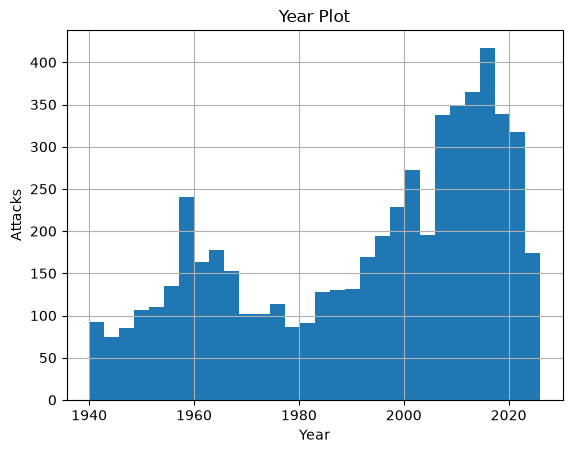

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


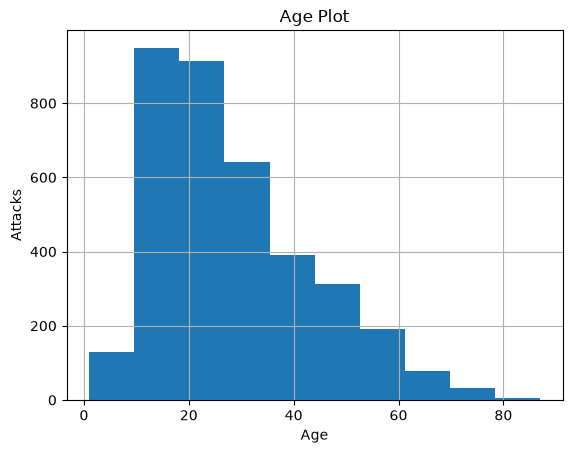

Male proportion: 0.8554146341463414
<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'UNprovoked',          'unprovoked',           ' Provoked',
          'Watercraft',        'Sea Disaster',                   nan,
                   '?',         'Unconfirmed',          'Unverified',
             'Invalid', 'Under investigation',                'Boat']
Length: 15, dtype: str
str
Unprovoked Proportion: 0.7459236695932628


In [9]:
# Question 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "./data/GSAF5.xls"
df = pd.read_excel(path)

# Drop columns that have no values at all
df = df.dropna(axis=1, how="all") 

# "Year" column type is float so convert to int
print(df["Year"].dtype)
df["Year_Clean"] = df["Year"].astype("Int64")
df = df[df["Year_Clean"] > 0]

# The min year is 5 and max year is 2026
min_year = df["Year_Clean"].min()
max_year = df["Year_Clean"].max()
print(f"Min Year: {min_year}")
print(f"Max Year: {max_year}")

# Filter to only years since 1940 and create plot to see the trend
# According to the plot, the attacks are generally increasing over time
df = df[df["Year_Clean"] >= 1940]
df["Year_Clean"].hist(bins=30)
plt.title("Year Plot")
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.show()

# Age has strings inside it and also type object so convert to numeric
print(df["Age"].unique())
print(df["Age"].dtype)
df["Age_Clean"] = pd.to_numeric(df["Age"], errors="coerce")

# Create histogram of age
df["Age_Clean"].hist()
plt.title("Age Plot")
plt.xlabel("Age")
plt.ylabel("Attacks")
plt.show()

# About 85% of the victims are male
sex_clean = df["Sex"].astype(str).str.strip().str.upper()
male_count = (df["Sex"] == "M").sum()
total_valid = sex_clean.isin(["M", "F"]).sum()
male_proportion = male_count / total_valid
print(f"Male proportion: {male_proportion}")

# Values in "Type" column are have different capitalizations so make function to normalize capitalization and assign unknown to ones that don't fit any category
print(df["Type"].unique())
print(df["Type"].dtype)

def normalize_type(type_value):
    normalized_type_value = str(type_value).capitalize()

    if normalized_type_value == "Provoked":
        return "Provoked"
    elif normalized_type_value == "Unprovoked":
        return "Unprovoked"
    else:
        return "Unknown"

# Apply function to column and assign to clean column
df["Type_Clean"] = df["Type"].apply(normalize_type)

# The unprovoked proportion is about 75%
unprovoked_count = (df["Type_Clean"] == "Unprovoked").sum()
total_rows = len(df)
unprovoked_proportion = unprovoked_count / total_rows
print(f"Unprovoked Proportion: {unprovoked_proportion}")

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements were small details that I overlooked, such as accounting for messy values (which I assumed were all clean) so that the values printed out as well as the interpretations would be more accurate. Another type of change was better data cleaning practices that didn't change the answer to questions but would be helpful to be aware of in the future, such as adding more bins to histograms to give a clearer picture or cleaner code with less lines to do the same logic. The AI sometimes made mistakes such as thinking the dollar sign was in the Price column for question 1.1 because it didn’t have access to the dataset. The final solution was verified by looking at whether the AI’s reasoning made sense (if it was within the scope of the problem and after looking at the dataset if the improvement was needed) and if the answer would be correctly printed out. 